In [7]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from ant.market import Market
from ant.agent import BaseAgent, BASE_UTILITY_TIMELINE
from ant.decentralised.direct import (
    ProportionalAgent,
    EqualDivisionAgent,
    OptimalAgent,
    GreedyAgent,
)
from ant.centralised import P4

In [8]:
class VolatileProportionalAgent(ProportionalAgent):
    def __init__(
        self,
        id: int,
        market: Optional[Market] = None,
        seed: Optional[int] = None,
        **kwargs,
    ):
        super().__init__(
            id,
            market,
            seed,
            **kwargs,
        )
        self.resource_value *= 0.05

    def reset(self):
        super().reset()
        self.production_timeline = np.array(
            [
                np.abs(self.random.gauss(self.endowment, 0.5))
                for _ in range(BASE_UTILITY_TIMELINE)
            ]
        )


class VolatilegGreedyAgent(GreedyAgent):
    def __init__(
        self,
        id: int,
        market: Optional[Market] = None,
        seed: Optional[int] = None,
        **kwargs,
    ):
        super().__init__(
            id,
            market,
            seed,
            **kwargs,
        )
        self.resource_value *= 0.05

    def reset(self):
        super().reset()
        self.production_timeline = np.array(
            [
                np.abs(self.random.gauss(self.endowment, 0.5))
                for _ in range(BASE_UTILITY_TIMELINE)
            ]
        )


class VolatileOptimalAgent(OptimalAgent):
    def __init__(
        self,
        id: int,
        market: Optional[Market] = None,
        seed: Optional[int] = None,
        **kwargs,
    ):
        super().__init__(
            id,
            market,
            seed,
            **kwargs,
        )
        self.resource_value *= 0.05

    def reset(self):
        super().reset()
        self.production_timeline = np.array(
            [
                np.abs(self.random.gauss(self.endowment, 0.5))
                for _ in range(BASE_UTILITY_TIMELINE)
            ]
        )

In [ ]:
# Demo experiment
market_size = 50
seed = 25
G = nx.gnp_random_graph(market_size, 0.11, seed=seed)
# nx.draw(G)
# Create different markets with the same topology and agent endowment and resource value (same seed is used)
# All markets use a different (homogenous) strategy
M1: Market = Market(
    market_size, graph=G, seed=seed, agent_type=VolatileProportionalAgent
)
M2: Market = Market(market_size, graph=G, seed=seed, agent_type=ProportionalAgent)
M3: Market = Market(market_size, graph=G, seed=seed, agent_type=VolatileOptimalAgent)
M4: Market = Market(market_size, graph=G, seed=seed, agent_type=OptimalAgent)
M5: Market = Market(market_size, graph=G, seed=seed, agent_type=GreedyAgent)
M6: Market = Market(market_size, graph=G, seed=seed, agent_type=VolatilegGreedyAgent)

In [ ]:
volatile_allocation_matrix, volatile_utility_vector = P4(M1)
normal_allocation_matrix, normal_utility_vector = P4(M2)
optimal_agents: List[OptimalAgent] = M4.agents
for agent in optimal_agents:
    agent.set_allocation_matrix(normal_allocation_matrix)

In [11]:
alphas = M1.resource_values * M1.endowments
size = len(alphas)
betas = np.empty((size, size))
for i in range(size):
    betas[i] = alphas

normal_allocation_matrix * betas

array([[ 9.14073082e-12, -9.51409516e-14,  4.82708809e-12, ...,
         1.34270849e-01, -1.83721907e-13,  1.95032075e-11],
       [-4.14105781e-13, -9.27726447e-12,  1.22322277e-08, ...,
         2.02342409e-09, -8.34634216e-12,  1.38652107e-11],
       [ 6.87076739e-12,  8.38808555e-09, -3.12543838e-13, ...,
        -2.45986900e-12, -3.63342847e-12,  2.07948846e-11],
       ...,
       [ 6.04355843e-01,  1.08511913e-08, -3.37986445e-12, ...,
        -1.92898408e-12, -2.83084247e-12,  4.25730348e-12],
       [-5.99077414e-13, -5.17054002e-12, -5.56908611e-12, ...,
        -3.16827307e-12, -4.64819158e-12,  6.93757657e-12],
       [ 2.45533794e-11,  5.05804546e-12,  1.83861211e-11, ...,
         2.97826652e-12,  4.29381692e-12,  4.37557480e-11]],
      shape=(50, 50))

In [ ]:
simulation_length = 1000
M1.set_market_equilibrium(volatile_allocation_matrix, volatile_utility_vector)
M2.set_market_equilibrium(normal_allocation_matrix, normal_utility_vector)
M3.set_market_equilibrium(volatile_allocation_matrix, volatile_utility_vector)
M4.set_market_equilibrium(normal_allocation_matrix, normal_utility_vector)
M5.set_market_equilibrium(normal_allocation_matrix, normal_utility_vector)
M6.set_market_equilibrium(volatile_allocation_matrix, volatile_utility_vector)
simulated_state_volatile_proportional = M1.simulate(simulation_length)
simulated_state_proportional = M2.simulate(simulation_length)
simulated_state_volatile_optimal = M3.simulate(
    simulation_length, use_average_in_market_loss=True
)
simulated_state_optimal = M4.simulate(
    simulation_length, use_average_in_market_loss=True
)
simulated_state_greedy = M5.simulate(simulation_length)
simulated_state_volatile_greedy = M6.simulate(simulation_length)

NameError: name 'simulated_state_proportional' is not defined

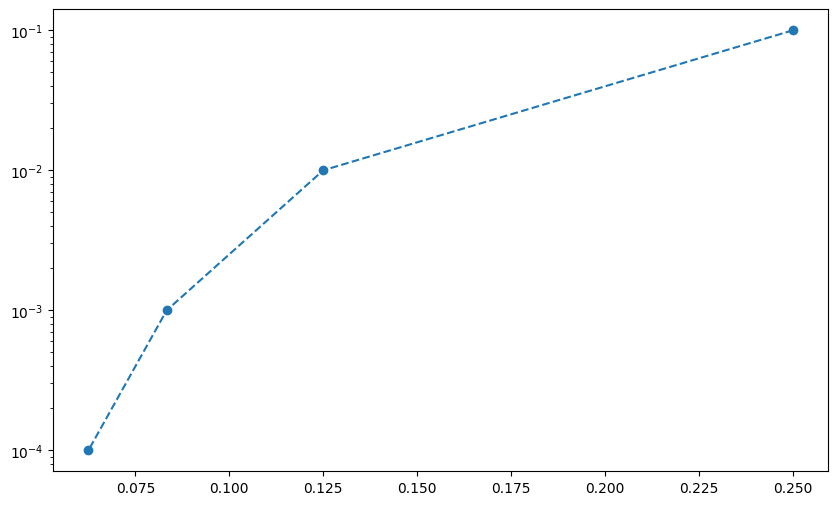

In [ ]:
window = (10, min(simulation_length, 1000))
# window = (100, 1000)
time_steps = np.arange(window[0], window[1])

plt.figure(figsize=(10, 6))
# log y axis
axis = plt.gca()
y_values = np.arange(1, 5)
x_values = np.arange(0, 4)
axis.semilogy(1 / (4 * y_values), 1 / (10**y_values), "o--")

plt.plot(
    time_steps,
    simulated_state_proportional[window[0] : window[1]],
    label="Proportional Agent",
    alpha=0.7,
)
plt.plot(
    time_steps,
    simulated_state_volatile_greedy[window[0] : window[1]],
    label="Greedy Agent",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_state_optimal[window[0] : window[1]],
    label="Optimal Division Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison, Normal Market")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# volatile-plot
plt.figure(figsize=(10, 6))
# log y axis
axis = plt.gca()
axis.semilogy(1 / (4 * y_values), 1 / (10**y_values), "o--")

plt.plot(
    time_steps,
    simulated_state_volatile_proportional[window[0] : window[1]],
    label="volatile Proportional Agent",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_state_volatile_greedy[window[0] : window[1]],
    label="volatile Greedy Agent",
    alpha=0.7,
)

plt.plot(
    time_steps,
    simulated_state_volatile_optimal[window[0] : window[1]],
    label="volatile Optimal Agent",
    alpha=0.7,
)

plt.xlabel("Time")
plt.ylabel("Loss")
plt.title("Strategy Comparison, Volitale Market")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()